<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 9.2: CNN with Keras
INSTRUCTIONS:
- Read the guides and hints, then create the necessary analysis and code to find an answer and conclusion for the task below.
- A guide you are encouraged to read through is TensorFlow's own tutorial for image classification, which can be found [here](https://www.tensorflow.org/tutorials/images/cnn)

## CIFAR10 small image classification
- [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset of color training images, labeled over 10 categories.

It has the classes:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

## Import libraries

In [ ]:
# Uncomment the statements below if there are problems with TensorFlow on macOS
# import os
# os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [74]:
# insert code here
# Import the library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from keras.utils import to_categorical
import seaborn as sns

In [3]:
# Uncomment the statement below to allow online monitoring with TensorBoard (need to be installed)
from keras.callbacks import TensorBoard

## Load data
Use the **Keras**' load method.

In [5]:
# insert code here
import keras
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [6]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## Check some data

In [8]:
def check_one(data, label, actual = None, id = None, compare = False):
    if id is None: 
        id = np.random.randint(data.shape[0])
    im = data[id]
    true_label_id = label[id][0]
    plt.figure(figsize=(3,3))
    plt.imshow(im)

    if compare and actual is not None and true_label_id != np.argmax(actual[id]):
        # Get the predicted label's ID from the one-hot encoded array
        predicted_label_id = np.argmax(actual[id])
        
        # Format the title to show the mismatch
        plt.title(f'class {true_label_id} ({classes[true_label_id]}) \n'
                  f'Predicted: {predicted_label_id} ({classes[predicted_label_id]})',
                  fontsize=10)
    else:
        # Simple title showing the true class name
        plt.title(f'class {true_label_id} ({classes[true_label_id]})')
        
    # Remove x and y ticks for cleaner visualization
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [9]:
def check_ten(data, label, actual = None, compare = False):
    # check ten
    fig, ax = plt.subplots(2, 5, figsize = (11, 5))
    plt.subplots_adjust(left=0.02, right=0.98, top=0.8, wspace=0.2, hspace=0.2)
    fig.suptitle('Check Data', fontsize = 12, fontweight = 'bold')
    plt.rcParams.update({'font.size': 10})
    
    ids = np.random.randint(data.shape[0], size = 10)
    r = 0
    c = 0
    for id in ids:
        im = data[id]
        # original image
        ax[r, c].imshow(im)
        
        l_id = label[id]
        if (compare) and (actual is not None) and (l_id != np.argmax(actual[id])):
            a_id = np.argmax(actual[id])
            ax[r, c].set_title('Class %d (%s) [\u2260 %d-%s]' % (l_id, classes[l_id], a_id, classes[a_id]))
        else:
            ax[r, c].set_title('Class %d (%s)' % (l_id, classes[l_id]))
        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])
        c += 1
        if c > 4:
            r += 1
            c = 0
    plt.show()

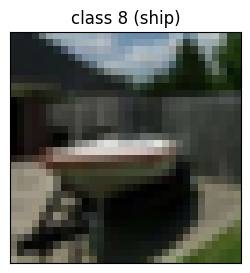

In [10]:
check_one(x_train, y_train)

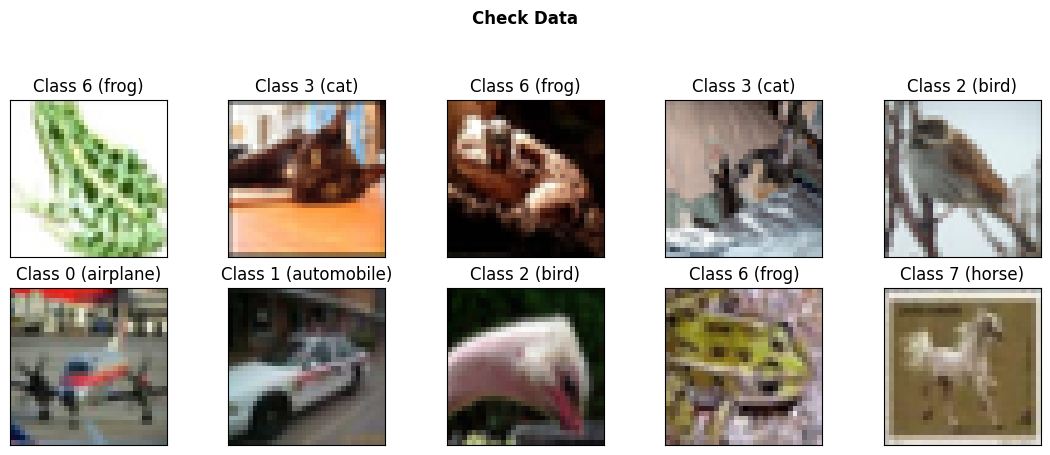

In [11]:
check_ten(x_train, y_train.flatten())

In [12]:
# insert code here
print(f"Shape of x_train: {x_train.shape}, dtype:{x_train.dtype}")
print(f"Shape of y_train: {y_train.shape}, dtype:{y_train.dtype}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Number of classes: {np.unique(y_train).shape[0]}")

Shape of x_train: (50000, 32, 32, 3), dtype:uint8
Shape of y_train: (50000, 1), dtype:uint8
Shape of x_test: (10000, 32, 32, 3)
Shape of y_test: (10000, 1)
Number of classes: 10


In [15]:
print(f"pixel value: {x_train[0][0][0][0]}")
print(f"label: {y_train[0][0]}\n")

pixel value: 59
label: 6



## Prepare data

In [25]:
# insert code here
# Normalize th image data
# Convert (0-255) pixel values to (0.0 - 1.0)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")

Shape of x_train: (50000, 32, 32, 3)
Shape of x_test: (10000, 32, 32, 3)


In [27]:
# Perform One-Hot Encoding the labels. 
# Convert multiclass (0-9) to Binary
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of y_train: (50000, 10)
Shape of y_test: (10000, 10)


## Create the model's architecture
- **NOTE ALERT**: Take into account the volume of data and parameters. Time and processing escalate quite fast.
- **NOTE ALERT**: It is likely this data will require more complex models.

In [30]:
# insert code here
model = Sequential()

In [32]:
# First Convolutional Block
input_shape = x_train.shape[1:]
num_classes = 10

model.add(Input(shape=input_shape))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Third Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flatten the 3D output into a 1D vector for the fully connected layers
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
# The final layer has 10 neurons (one for each class) with a softmax activation.
# Softmax outputs a probability distribution over the classes.
model.add(Dense(num_classes, activation='softmax'))

In [34]:
# model.add(Conv2D(48, kernel_size= 3, activation= 'relu', padding= 'same', input_shape=(32,32,32)))
# model.add(Conv2D(48, kernel_size= 3, activation= 'relu'))
# model.add(MaxPool2D(pool_size =(2,2)))
# model.add(Dropout(0.25))
# model.add(Conv2D(96, kernel_size= 3, activation= 'relu', padding= 'same'))
# model.add(Conv2D(96, kernel_size= 3, activation= 'relu'))
# model.add(MaxPool2D(pool_size =(2,2)))
# model.add(Dropout(0.25))
# model.add(Conv2D(192, kernel_size= 3, activation='relu', padding='same'))
# model.add(Conv2D(192, kernel_size= 3, activation='relu'))
# model.add(MaxPool2D(pool_size =(2,2)))
# model.add(Dropout(0.25))
# model.add(Flatten())
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(256, activation='relu'))
# model.add(Dense(num_classes, activation='softmax'))

## Compile the model

In [37]:
# insert code here
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,147,466 (4.38 MB)

 Trainable params: 1,147,466 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

## Fit the training data

In [42]:
# Uncomment the statement below to allow online monitoring with TensorBoard
tensorboard = TensorBoard(log_dir = 'logs') # choose or create a directory for the logs

In [44]:
%%time
# insert code here
# Create a unique log directory with a timestamp to avoid overwriting previous runs

mod = model.fit(
    x_train,
    y_train,
    batch_size=64, # Number of samples per gradient update
    epochs=5,      # Number of full passes over the training data
    validation_data=(x_test, y_test), # Use the test set for validation
    callbacks = [tensorboard],
    verbose=1       # Show training progress bar
)

#
# ..., callbacks = [tensorboard], ...

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.4067 - loss: 1.6234 - val_accuracy: 0.5477 - val_loss: 1.2560
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.5634 - loss: 1.2277 - val_accuracy: 0.6262 - val_loss: 1.0520
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.6225 - loss: 1.0713 - val_accuracy: 0.6839 - val_loss: 0.9080
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.6567 - loss: 0.9726 - val_accuracy: 0.6930 - val_loss: 0.8761
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.6797 - loss: 0.9120 - val_accuracy: 0.7065 - val_loss: 0.8369
CPU times: total: 19min 28s
Wall time: 3min 30s


### TensorBoard
- TensorBoard is TensorFlow's visualisation toolkit.
- If Tensorflow 2 and Jupyter is installed in the same environment, running the cell below will start TensorBoard within the notebook.
- More information about how to set up TensorBoard can be found [here](https://www.tensorflow.org/tensorboard/tensorboard_in_notebooks)


In [46]:
%load_ext tensorboard
%tensorboard --logdir logs --port 7009

In [47]:
# Uncomment and run the code below if unable to visualise TensorBoard a second time.
# %reload_ext tensorboard
# %tensorboard --logdir logs --port=6007

## Create predictions

In [53]:
# insert code here
predictions = model.predict(x_test)
pred = np.argmax(predictions, axis=1)
print(f"Shape of y_pred: {pred.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Shape of y_pred: (10000,)


## Evaluate the model

In [55]:
# insert code here
score = model.evaluate(x_test, y_test)
print(score[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7065 - loss: 0.8369
0.8369406461715698


## Visualisation of cost

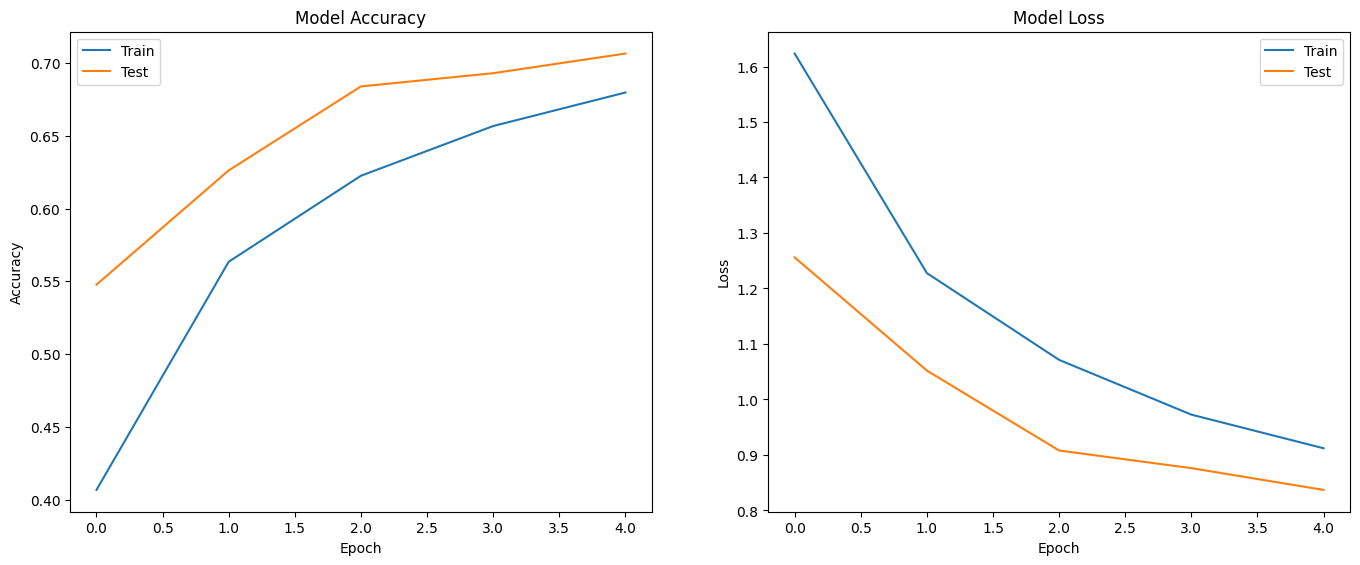

In [58]:
# insert code here
fig, ax = plt.subplots(1,2, figsize = (16,6))
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

ax[0].plot(mod.history['accuracy'], label='Train')
ax[0].plot(mod.history['val_accuracy'], label ='Test')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(mod.history['loss'], label='Train')
ax[1].plot(mod.history['val_loss'], label ='Test')
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.show()

## Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Shape of y_test: (10000,)
Shape of y_pred: (10000,)


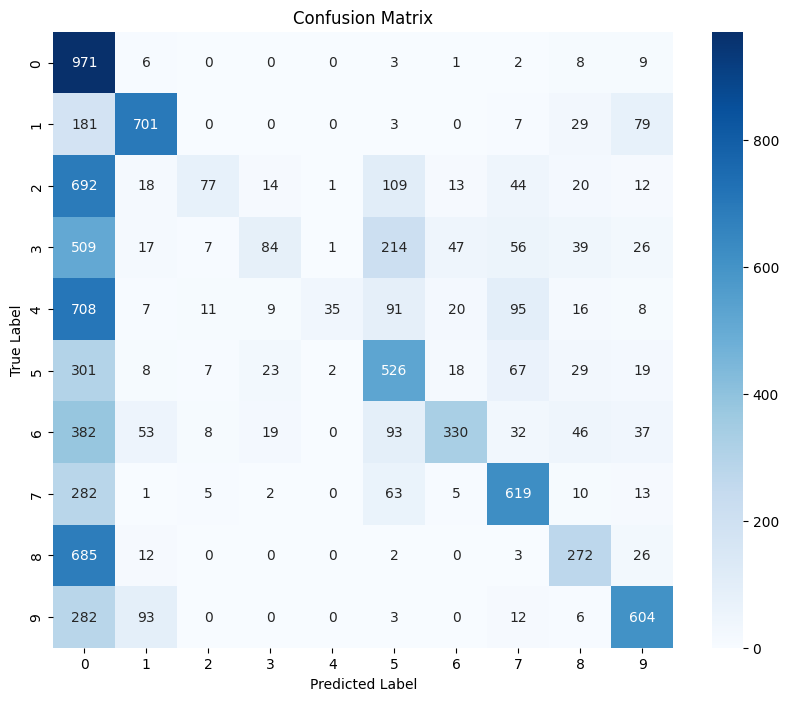


Classification report:
              precision    recall  f1-score   support

           0       0.19      0.97      0.32      1000
           1       0.77      0.70      0.73      1000
           2       0.67      0.08      0.14      1000
           3       0.56      0.08      0.15      1000
           4       0.90      0.04      0.07      1000
           5       0.48      0.53      0.50      1000
           6       0.76      0.33      0.46      1000
           7       0.66      0.62      0.64      1000
           8       0.57      0.27      0.37      1000
           9       0.73      0.60      0.66      1000

    accuracy                           0.42     10000
   macro avg       0.63      0.42      0.40     10000
weighted avg       0.63      0.42      0.40     10000



In [76]:
# insert code here
(_, _), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test = y_test.flatten()

print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of y_pred: {y_pred.shape}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(num_classes),
            yticklabels=range(num_classes))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("\nClassification report:")
print(classification_report(y_test, y_pred))



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



